In [1]:
from __future__ import annotations

import anndata
import pandas as pd
import scanpy as sc
from matplotlib import pyplot as plt

In [2]:
# note that this collection of batches is already intersected on the genes
anndata = sc.read(
    "data/pancreas.h5ad",
    backup_url="https://www.dropbox.com/s/qj1jlm9w10wmt0u/pancreas.h5ad?dl=1",
)
anndata

/anaconda3/envs/bibola/lib/python3.11/site-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{
/anaconda3/envs/bibola/lib/python3.11/site-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  return AnnData(**{


AnnData object with n_obs × n_vars = 14693 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [3]:
counts = anndata.obs["celltype"].value_counts()
counts.to_frame()

,count
celltype,
alpha,4214
beta,3354
ductal,1804
acinar,1368
not applicable,1154
delta,917
gamma,571
endothelial,289
activated_stellate,284


In [4]:
minority_classes = counts.index[-5:].tolist()  # get the minority classes
# actually subset
anndata = anndata[~anndata.obs["celltype"].isin(minority_classes)].copy()
# reorder according to abundance
anndata.obs["celltype"] = anndata.obs["celltype"].cat.reorder_categories(counts.index[:-5].tolist())
anndata.obs

,celltype,sample,n_genes,batch,n_counts,louvain
index,,,,,,
human1_lib1.final_cell_0001-0,acinar,Baron,3526,0,2.241100e+04,2
human1_lib1.final_cell_0002-0,acinar,Baron,4201,0,2.794900e+04,2
human1_lib1.final_cell_0003-0,acinar,Baron,2119,0,1.689200e+04,2
human1_lib1.final_cell_0004-0,acinar,Baron,2956,0,1.929900e+04,2
human1_lib1.final_cell_0005-0,acinar,Baron,2715,0,1.506700e+04,2
...,...,...,...,...,...,...
reads.29499-3,ductal,Wang,19950,3,1.056558e+06,10
reads.29500-3,ductal,Wang,19950,3,9.926309e+05,10
reads.29501-3,beta,Wang,19950,3,1.751338e+06,10


In [5]:
sc.pp.pca(anndata)
sc.pp.neighbors(anndata)
sc.tl.umap(anndata)

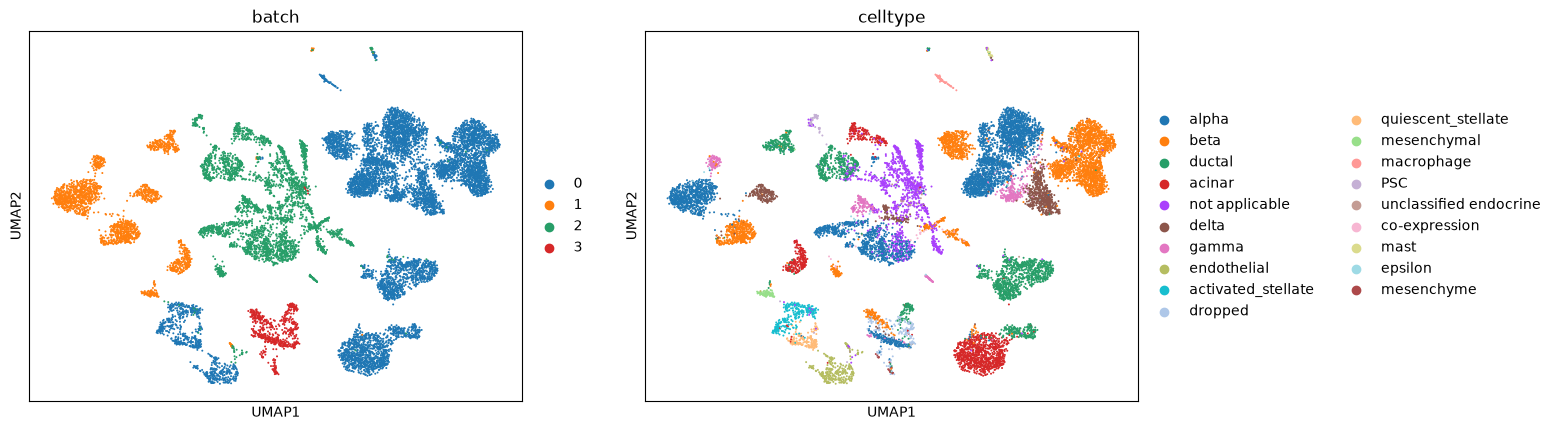

In [6]:
# original UMAP (without batch correction)
sc.pl.umap(anndata, color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)

In [7]:
import torch

from bibola.model import ChunkIntegration

In [8]:
batch_correction_model = ChunkIntegration(
    in_channels=anndata.obsm["X_pca"].shape[1],
    hidden_channels=[1024,],
    out_channels=50,
    dropout=0.1,
    optimizer_kwargs={"lr": 1e-4}
)
batch_correction_model

ChunkIntegration(in_channels=50, hidden_channels=[1024], out_channels=50, optimizer=Adam, not fitted)

In [17]:
batch_correction_model.loss_history

loss                          loss_weights                       
  abs_lisa_loss topology_loss  knn_loss abs_lisa_loss topology_loss knn_loss
0      0.043516     -0.903870 -0.249630          0.25          0.75      2.0
1      0.035294     -0.912734 -0.327630          0.25          0.75      2.0
2      0.031046     -0.914273 -0.402093          0.25          0.75      2.0
3      0.029059     -0.908925 -0.469945          0.25          0.75      2.0
4      0.028158     -0.902173 -0.526173          0.25          0.75      2.0

In [9]:
batch_correction_model.fit(
    anndata.obsm["X_pca"], anndata.obs["batch"], epochs=5, lr=1e-4,
    print_every=1, k_inter=5, k_intra=100, norm=1,
    loss_weights={"abs_lisa_loss":.25, "topology_loss": .75, "knn_loss": 2.},
    n_chunks=5
)

In [11]:
anndata.obsm["X_corrected"] = batch_correction_model.transform(
    anndata.obsm["X_pca"], anndata.obs["batch"]
).numpy()

from sklearn.decomposition import PCA

# we apply PCA to reduce the collinearity after the batch correction.
pca_model = PCA(n_components=50)
anndata.obsm["X_corrected"] = pca_model.fit_transform(anndata.obsm["X_corrected"])
anndata

AnnData object with n_obs × n_vars = 14662 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors'
    obsm: 'X_pca', 'X_umap', 'X_corrected'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [12]:
sc.pp.neighbors(anndata, use_rep="X_corrected", key_added="neighbors_corrected")
sc.tl.umap(anndata, neighbors_key="neighbors_corrected", key_added="umap_corrected")
anndata

AnnData object with n_obs × n_vars = 14662 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors', 'neighbors_corrected', 'umap_corrected'
    obsm: 'X_pca', 'X_umap', 'X_corrected', 'umap_corrected'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities'

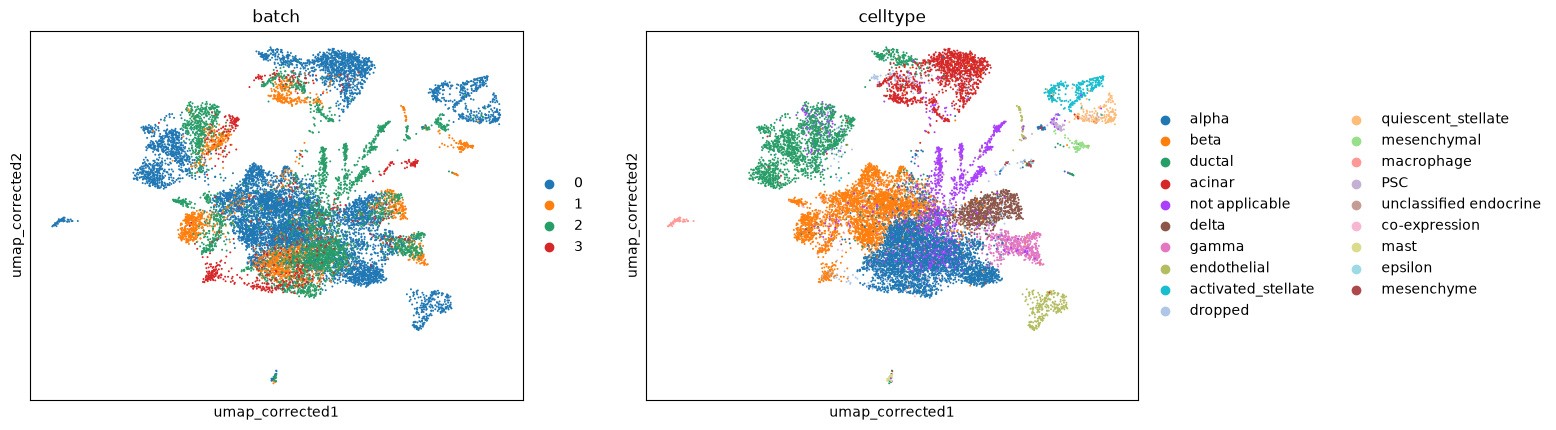

In [13]:
sc.pl.embedding(anndata, basis="umap_corrected", color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)
# UMAP after batch correction via bibola

In [14]:
from harmonypy import run_harmony

In [15]:
anndata.obsm["X_pca_harmony"] = run_harmony(anndata.obsm["X_pca"], anndata.obs, "batch").Z_corr
anndata.obsm["X_pca_harmony"]

2026-08-11 16:56:06,541 - harmonypy - INFO - Running Harmony
2026-08-11 16:56:06,542 - harmonypy - INFO -   Parameters:
2026-08-11 16:56:06,542 - harmonypy - INFO -     max_iter_harmony: 10
2026-08-11 16:56:06,542 - harmonypy - INFO -     max_iter_kmeans: 4
2026-08-11 16:56:06,543 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-08-11 16:56:06,543 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-08-11 16:56:06,544 - harmonypy - INFO -     nclust: 100
2026-08-11 16:56:06,544 - harmonypy - INFO -     block_size: 0.05
2026-08-11 16:56:06,544 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-08-11 16:56:06,545 - harmonypy - INFO -     theta: [2. 2. 2. 2.]
2026-08-11 16:56:06,545 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-08-11 16:56:06,546 - harmonypy - INFO -     verbose: True
2026-08-11 16:56:06,546 - harmonypy - INFO -     random_state: 0
2026-08-11 16:56:06,547 - harmonypy - INFO -   Data: 50 PCs × 14662 cells
2026-08-11 16:56:06,548 - harmonypy - INFO -

array([[  0.15425171,  -4.53972244,  -8.52065468, ...,  -0.38841876,
         -1.45698595,   0.08615991],
       [  3.89552402,  -4.51804066, -10.26223946, ...,  -1.12404025,
          0.90807426,   0.02703966],
       [ -3.71449828,  -4.54087257,  -6.43288279, ...,  -0.76113915,
          0.75945079,   0.08842079],
       ...,
       [  2.96661663,  10.92668152,   5.37792253, ...,   4.19615793,
          1.68354046,   0.28366753],
       [ 14.31705666,  -1.82588816, -12.1900053 , ...,   1.48150325,
          0.90651804,   1.02317023],
       [  3.00160837,  12.04156685,   4.41478348, ...,   0.0424562 ,
          0.6069088 ,   1.26845121]], shape=(14662, 50))

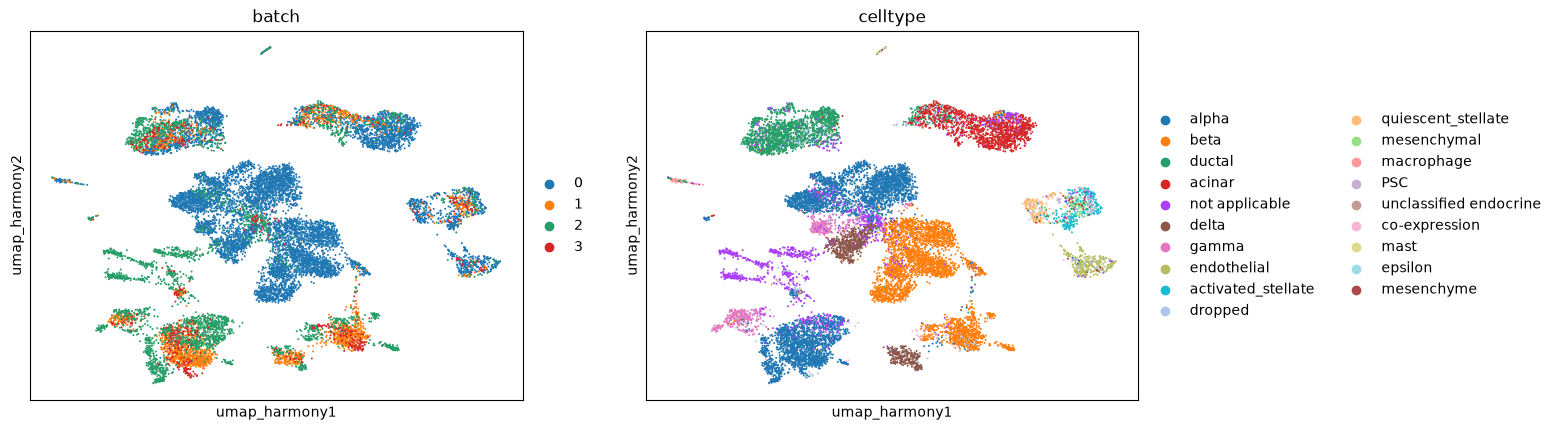

In [16]:
sc.pp.neighbors(anndata, use_rep="X_pca_harmony", key_added="neighbors_harmony")
sc.tl.umap(anndata, neighbors_key="neighbors_harmony", key_added="umap_harmony")
sc.pl.embedding(anndata, color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy, basis="umap_harmony")
# UMAP after batch correction via harmony

In [18]:
# We can even consider to run the bibola workflow starting from harmony correction, instead of PCA.
# This in order to have a warmer initializzation of the gradient, since the data is already well integrated and we just need to refine the integration at a local level..
# In this case, we will prioritize the spatial autocorrelation (LIBSA) loss since the batches are already "close" enough.

In [20]:
batch_correction_model = ChunkIntegration(
    in_channels=anndata.obsm["X_pca_harmony"].shape[1],
    hidden_channels=[1024,],
    out_channels=50,
    dropout=0.1,
    optimizer_kwargs={"lr": 1e-4}
)
batch_correction_model

ChunkIntegration(in_channels=50, hidden_channels=[1024], out_channels=50, optimizer=Adam, not fitted)

In [21]:
batch_correction_model.fit(
    anndata.obsm["X_pca_harmony"], anndata.obs["batch"], epochs=5, lr=1e-4,
    print_every=1, k_inter=5, k_intra=100, norm=1,
    loss_weights={"abs_lisa_loss":.25, "topology_loss": .75, "knn_loss": 2.},
    n_chunks=5
)

In [24]:
batch_correction_model.loss_history

loss                          loss_weights                       
  abs_lisa_loss topology_loss  knn_loss abs_lisa_loss topology_loss knn_loss
0      0.033066     -0.887432 -0.252100          0.25          0.75      2.0
1      0.026592     -0.899705 -0.313932          0.25          0.75      2.0
2      0.023014     -0.903769 -0.371598          0.25          0.75      2.0
3      0.021539     -0.901387 -0.425402          0.25          0.75      2.0
4      0.019877     -0.897680 -0.475372          0.25          0.75      2.0

In [22]:
anndata.obsm["X_corrected_after_harmony"] = batch_correction_model.transform(
    anndata.obsm["X_pca_harmony"], anndata.obs["batch"]
).numpy()

from sklearn.decomposition import PCA

pca_model = PCA(n_components=50)
anndata.obsm["X_corrected_after_harmony"] = pca_model.fit_transform(anndata.obsm["X_corrected_after_harmony"])
anndata

AnnData object with n_obs × n_vars = 14662 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors', 'neighbors_corrected', 'umap_corrected', 'neighbors_harmony', 'umap_harmony'
    obsm: 'X_pca', 'X_umap', 'X_corrected', 'umap_corrected', 'X_pca_harmony', 'umap_harmony', 'X_corrected_after_harmony'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities', 'neighbors_harmony_distances', 'neighbors_harmony_connectivities'

In [23]:
sc.pp.neighbors(anndata, use_rep="X_corrected_after_harmony", key_added="neighbors_corrected_after_harmony")
sc.tl.umap(anndata, neighbors_key="neighbors_corrected_after_harmony", key_added="umap_corrected_after_harmony")
anndata

AnnData object with n_obs × n_vars = 14662 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors', 'neighbors_corrected', 'umap_corrected', 'neighbors_harmony', 'umap_harmony', 'neighbors_corrected_after_harmony', 'umap_corrected_after_harmony'
    obsm: 'X_pca', 'X_umap', 'X_corrected', 'umap_corrected', 'X_pca_harmony', 'umap_harmony', 'X_corrected_after_harmony', 'umap_corrected_after_harmony'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities', 'neighbors_harmony_distances', 'neighbors_harmony_connectivities', 'neighbors_corrected_after_harmony_distances', 'neighbors_corrected_after_harmony_connectivities'

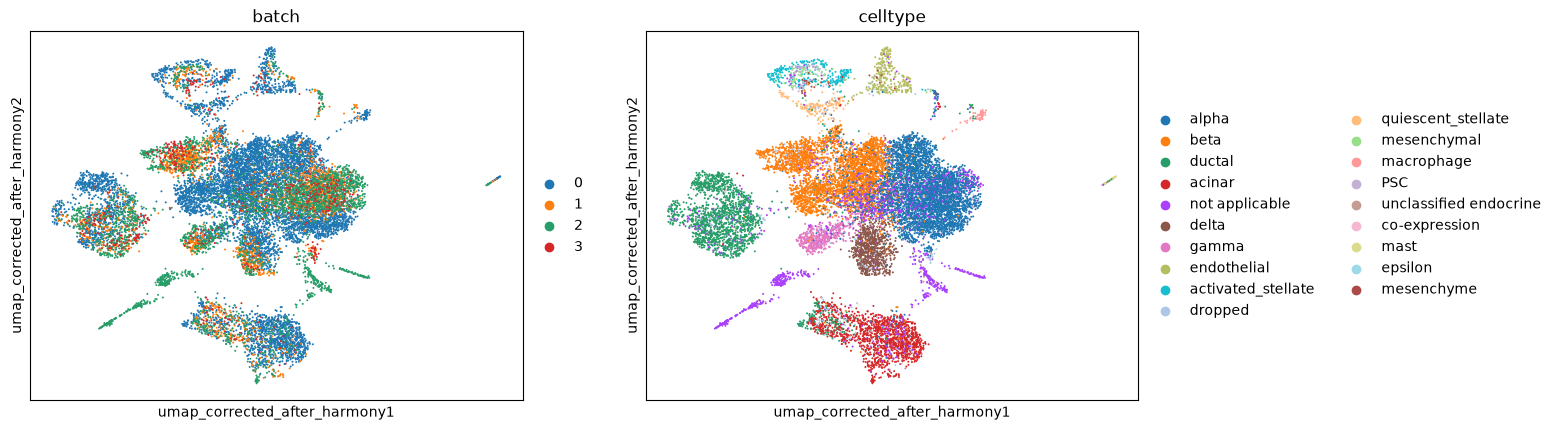

In [25]:
sc.pl.embedding(anndata, basis="umap_corrected_after_harmony", color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)
# UMAP after batch correction via bibola, starting from harmony
# we see an improvement in the integration of the batches, and a better separation of the cell types, compared to harmony alone.